# Ejercicio 3 — Volatilidad determinista y opción asiática

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

## Datos y recorrido de la resolución

El activo satisface

$$dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t,$$

con $\sigma(t)$ determinista, $S_0=100$ y tipo continuo $r=1\%=0.01$. Interpretamos esta dinámica bajo la medida neutral al riesgo, sin dividendos. El tiempo se expresa en años.

Las calls europeas tienen strike común $K=100$:

| Vencimiento T | Precio de mercado |
|---|---|
| 1 año | 9.55 |
| 1.25 años | 12.48 |
| 2 años | 23.36 |

Se pide verificar la solución explícita, derivar la fórmula europea, calibrar $\sigma(t)=at^2+bt+c$ y valorar una asiática aritmética con fijaciones en $1.15$, $1.30$, $1.60$ y $1.70$ años y pago en $2$ años.

La idea que conecta la resolución es:

$$\boxed{\sigma(t)\ \longrightarrow
V(T)=\int_0^T\sigma^2(s)\,ds
\longrightarrow\ \text{precio de la call europea}}.$$

Como $\sigma(t)$ es determinista, toda su influencia sobre la distribución terminal $S_T$ se resume en la **varianza acumulada** $V(T)$. Primero verificaremos el modelo y obtendremos el precio europeo; después recorreremos el camino inverso, desde tres precios hasta la curva de volatilidad. Para la asiática usaremos esa misma curva, pero necesitaremos $V$ en las cuatro fijaciones y la dependencia entre ellas, no solo en una fecha.

## Configuración del entorno


**Ejecución:** Python 3, NumPy, pandas, Matplotlib y SciPy; Jupyter/IPython para visualizar. Reiniciar el kernel y ejecutar todas las celdas en orden. No se leen ni escriben archivos auxiliares. Las semillas están fijadas y las figuras quedan embebidas en el notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
from scipy.optimize import brentq, root
from scipy.stats import norm, qmc, t as student_t
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.prop_cycle": plt.cycler(color=["#001391", "#1973b8", "#5e9cc9"]),
    "axes.grid": True,
    "grid.alpha": 0.15,
    "axes.titleweight": "bold",
})


S0 = 100.0
K = 100.0
r = 0.01
VENCIMIENTOS = np.array([1.0, 1.25, 2.0])
PRECIOS = np.array([9.55, 12.48, 23.36])
print(f"S0={S0:.0f}, K={K:.0f}, r={r:.2%}")


S0=100, K=100, r=1.00%


---

### Mapa del ejercicio 3

Todo el ejercicio sigue una sola cadena de ideas:

$$
\boxed{
\text{SDE}
\xrightarrow{3.1} S_t
\xrightarrow{3.2} C(T)
\xrightarrow{3.3} \sigma(t)\text{ calibrada}
\xrightarrow{3.4} C_{\mathrm{asiática}}
}
$$

Primero comprobamos la dinámica del precio. Después obtenemos su distribución terminal, usamos precios de mercado para recuperar la curva de volatilidad y, por último, utilizamos esa misma curva para valorar una opción que depende de varias fijaciones.

---

## Apartado 3.1 — Verificación de la solución explícita

Queremos comprobar que la expresión propuesta

$$S_t=S_0\exp\left(rt-\frac12\int_0^t\sigma^2(s)\,ds
+\int_0^t\sigma(s)\,dW_s\right)$$

reproduce exactamente la SDE $dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t$ al aplicarle Itô, y que parte del valor inicial $S_0$.

El término $-\frac12\int_0^t\sigma^2(s)\,ds=-V(t)/2$ no es arbitrario: la exponencial introduce una corrección de segundo orden positiva. Esa resta está preparada para compensarla y dejar la deriva final en $rS_t\,dt$.

### 1. Separar el exponente para aplicar Itô

Suponemos $\int_0^T\sigma^2(s)\,ds<\infty$ en cada horizonte finito, como ocurre para la volatilidad cuadrática. Con $V(t)=\int_0^t\sigma^2(s)\,ds$, definimos

$$X_t=rt-\frac12V(t)+\int_0^t\sigma(s)\,dW_s.$$

Así, $S_t=S_0e^{X_t}$. La ventaja de introducir $X_t$ es que podemos trabajar en dos pasos: primero entendemos cómo cambia el exponente y después propagamos ese cambio a través de la exponencial usando Itô.

Calculamos $dX_t$ **término a término**.

Para la parte determinista,

$$
d(rt)=r\,dt.
$$

Por el teorema fundamental del cálculo,

$$
d\left(
-\frac12\int_0^t\sigma^2(s)\,ds
\right)
=
-\frac12\sigma^2(t)\,dt.
$$

Y, por definición de la integral de Itô,

$$
d\left(
\int_0^t\sigma(s)\,dW_s
\right)
=
\sigma(t)\,dW_t.
$$

Por tanto,

$$
\boxed{
dX_t=
\underbrace{\left(r-\frac12\sigma^2(t)\right)dt}_{\text{parte de variación finita}}
+
\underbrace{\sigma(t)\,dW_t}_{\text{parte browniana}}
}.
$$

Aquí $d(\cdot)$ representa el **diferencial del proceso**. No debe interpretarse como una derivada temporal clásica: las trayectorias brownianas son continuas, pero casi seguramente no son derivables.

Ahora necesitamos la variación cuadrática de $X_t$. Para ver de dónde sale, expandimos formalmente el cuadrado del diferencial:

$$
(dX_t)^2=
\left[
\left(r-\frac12\sigma^2(t)\right)dt+
\sigma(t)dW_t
\right]^2.
$$

En cálculo de Itô usamos las reglas de orden

$$
(dt)^2=0,\qquad dt\,dW_t=0,\qquad (dW_t)^2=dt.
$$

Los términos que contienen $(dt)^2$ o $dt\,dW_t$ desaparecen. Solo sobrevive el cuadrado del término browniano:

$$
\boxed{
d\langle X\rangle_t=\sigma^2(t)\,dt
}.
$$

Esta notación resume la variación cuadrática acumulada por el ruido. No aparece una derivada de $\sigma(t)$: estamos diferenciando una integral, no el producto $\sigma(t)W_t$.

### 2. Verificar la cancelación en la exponencial

Las dos primeras derivadas de $f(\ell)=S_0e^\ell$ son iguales a $f(\ell)$. Por Itô,

$$dS_t=S_t\,dX_t+\frac12S_t\,d\langle X\rangle_t.$$

Sustituimos ahora los dos diferenciales. La cancelación clave es exactamente

$$
-\frac12S_t\sigma^2(t)\,dt
+\frac12S_t\sigma^2(t)\,dt
=0.
$$

Por eso la corrección $-\frac12\int_0^t\sigma^2(s)\,ds$ del exponente no era decorativa: compensa el término de segundo orden generado por Itô.

Sustituyendo,

$$dS_t=S_t\left[\left(r-\frac12\sigma^2(t)\right)dt
+\sigma(t)\,dW_t\right]+\frac12S_t\sigma^2(t)\,dt.$$

La resta del exponente y la corrección de Itô se cancelan:

$$\boxed{dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t}.$$

Además, $X_0=0$, luego $S_0e^{X_0}=S_0$. Quedan verificadas la dinámica y la condición inicial.

### 3. Interpretar el resultado

Sin $-V(t)/2$, la deriva sería $(r+\sigma^2(t)/2)S_t\,dt$, no la del enunciado. La misma compensación mantiene $E[S_t]=S_0e^{rt}$: la integral gaussiana tiene varianza $V(t)$ y la esperanza de su exponencial es $e^{V(t)/2}$, que cancela el factor $e^{-V(t)/2}$. La solución también mantiene $S_t>0$ si $S_0>0$.

Ya conocemos la forma del precio. El siguiente paso es usar su distribución en el vencimiento para valorar la call.


---

## Apartado 3.2 — Fórmula analítica de la call europea

**Qué pide el enunciado.** Obtener la fórmula analítica del precio de una call europea con strike $K$ y vencimiento $T$, cuando el activo sigue la solución de 3.1.

En el apartado 1 hemos conseguido describir $S_T$. Ahora necesitamos utilizar esa distribución terminal para calcular el valor esperado descontado del payoff de una call. $K>0$ es el precio de ejercicio y $T>0$ el tiempo hasta vencimiento. El pago en esa fecha es

$$(S_T-K)^+=\max(S_T-K,0).$$

La notación $x^+=\max(x,0)$ significa parte positiva: se cobra el exceso sobre $K$ si lo hay; en otro caso, cero.

### 1. Localizar la incertidumbre terminal

Partimos de la solución verificada:

$$S_T=S_0\exp\left(rT-\frac12\int_0^T\sigma^2(s)\,ds
+\int_0^T\sigma(s)\,dW_s\right).$$

La parte $rT-\frac12\int_0^T\sigma^2(s)\,ds$ es determinista: queda fijada al conocer el tipo, el horizonte y la curva de volatilidad. Definimos por separado

$$I_T=\int_0^T\sigma(s)\,dW_s.$$

$I_T$ acumula los shocks hasta $T$. Toda la incertidumbre de $S_T$ está concentrada en esta variable; por eso debemos entender su distribución antes de valorar el payoff.

$$\boxed{I_T\text{ es el shock aleatorio acumulado hasta }T}$$

### 2. Entender la integral mediante pequeños shocks

Dividimos $[0,T]$ en intervalos $[t_i,t_{i+1}]$, de longitud $\Delta t_i=t_{i+1}-t_i$. Para una curva continua, la integral se aproxima mediante

$$I_T\approx\sum_i\sigma(t_i)\Delta W_i,
\qquad \Delta W_i=W_{t_{i+1}}-W_{t_i}.$$

$\Delta W_i$ es el incremento browniano de ese intervalo. Por la definición de Browniano estándar,

$$\Delta W_i\sim N(0,\Delta t_i).$$

$N(\mu,v)$ denota una normal de media $\mu$ y varianza $v$. Los incrementos de intervalos disjuntos son independientes. Cada $\sigma(t_i)\Delta W_i$ es, por tanto, un shock browniano escalado por la volatilidad instantánea; la integral suma sus efectos.

Al refinar la partición, estas sumas convergen en media cuadrática a $I_T$: el error cuadrático esperado tiende a cero. Para una $\sigma$ determinista solo cuadrado-integrable, se utilizan aproximaciones escalonadas en $L^2$, con el mismo argumento.

### 3. Media cero: compensación entre trayectorias

Cada shock tiene media cero y $\sigma(t_i)$ es un coeficiente determinista:

$$E[\sigma(t_i)\Delta W_i]=\sigma(t_i)E[\Delta W_i]=0.$$

La esperanza de la suma es la suma de las esperanzas; la convergencia en media cuadrática permite pasar al límite. Así,

$$\boxed{E[I_T]=0}.$$

**Esto no significa $I_T=0$.** Significa que, entre muchas trayectorias, los shocks positivos y negativos se compensan en promedio. En una trayectoria concreta $\omega$, el valor $I_T(\omega)$ puede ser positivo o negativo. $\omega$ identifica una realización del azar, no una nueva variable temporal.

### 4. Varianza: cuánto fluctúa esa suma

La varianza mide la dispersión alrededor de la media. Si $q$ es un número determinista y $U$ una variable con segundo momento finito,

$$\operatorname{Var}(qU)=E[(qU-qE[U])^2]
=q^2\operatorname{Var}(U).$$

El coeficiente se eleva al cuadrado porque la varianza usa desviaciones al cuadrado. Aplicándolo a cada shock,

$$\operatorname{Var}(\sigma(t_i)\Delta W_i)=\sigma^2(t_i)\Delta t_i.$$

La independencia anula las covarianzas entre intervalos. Por eso sus varianzas se suman:

$$\operatorname{Var}\left(\sum_i\sigma(t_i)\Delta W_i\right)
=\sum_i\sigma^2(t_i)\Delta t_i.$$

Al pasar al límite en media cuadrática, convergen también los segundos momentos. La suma de la derecha converge a una integral temporal:

$$\boxed{\operatorname{Var}(I_T)=E[I_T^2]
=\int_0^T\sigma^2(s)\,ds=V(T)}.$$

Esta es la **isometría de Itô** en este contexto; usamos $E[I_T]=0$ para identificar segundo momento y varianza. $V(T)$ es la **varianza acumulada del shock logarítmico**, no la varianza del precio $S_T$.

$$\boxed{V(T)\text{ es la varianza acumulada de }I_T}$$

No hemos sustituido $\int\sigma\,dW$ por $\int\sigma^2\,dt$: la primera es una variable aleatoria; la segunda describe su varianza y es determinista.

Como recordatorio intuitivo, la regla de Itô $(dW_t)^2=dt$ resume que los cuadrados de los incrementos acumulan tiempo. No afirma que $(\Delta W_i)^2=\Delta t_i$ en cada realización. El argumento mediante sumas, independencia y límite explica por qué aparece aquí $\sigma^2\,dt$.

### 5. Por qué el shock es normal

Cada suma $\sum_i\sigma(t_i)\Delta W_i$ es una combinación lineal de gaussianas independientes con coeficientes deterministas. Por ello es normal, con media cero y la varianza calculada arriba.

Sus varianzas convergen a $V(T)$, de modo que sus leyes normales convergen a $N(0,V(T))$. Como esas mismas sumas convergen en media cuadrática a $I_T$, también convergen en distribución a $I_T$. Ambos límites tienen la misma ley:

$$\boxed{I_T\sim N(0,V(T))}.$$

La condición determinista importa: una integral de Itô con integrando aleatorio no tiene por qué ser normal.

Introducimos $Z\sim N(0,1)$ para expresar el shock usando una normal estándar:

$$I_T\overset d=\sqrt{V(T)}\,Z.$$

$\overset d=$ significa **igualdad en distribución**: ambos lados tienen las mismas probabilidades. La letra $d$ no es un diferencial; la notación tampoco identifica literalmente sus trayectorias. Aparece $\sqrt{V(T)}$ porque la desviación típica es la raíz de la varianza. Es el producto $\sqrt{V(T)}\,Z$, **no** $\sqrt{V(T)Z}$.

$$\boxed{I_T\overset d=\sqrt{V(T)}\,Z,\qquad Z\sim N(0,1)}$$

### 6. De un shock normal a un precio lognormal

Transformamos esa igualdad en distribución mediante la exponencial:

$$S_T\overset d=S_0\exp\left(rT-\frac12V(T)+\sqrt{V(T)}\,Z\right).$$

Por tanto,

$$\log S_T\sim N\left(\log S_0+rT-\frac12V(T),\,V(T)\right).$$

Una variable positiva es **lognormal** cuando su logaritmo sigue una normal. Así queda caracterizado el objeto que necesita la call: la distribución terminal del precio.

¿Por qué importa la dispersión si el shock tiene media cero? La exponencial no es lineal: $E[e^{I_T}]\ne e^{E[I_T]}$ en general. Completando el cuadrado en la densidad normal se obtiene $E[e^{\sqrt V Z}]=e^{V/2}$, con $V=V(T)$. La compensación del exponente mantiene

$$E[S_T]=S_0e^{rT},\qquad
\operatorname{Var}(S_T)=S_0^2e^{2rT}(e^V-1).$$

La segunda identidad resulta de $E[S_T^2]=S_0^2e^{2rT+V}$ menos $E[S_T]^2$. Al aumentar $V$, se conserva la media del precio y aumenta su dispersión.

El payoff de la call es convexo y asimétrico: los precios muy altos aportan ganancias grandes; los bajos dejan un pago cero. Conocer solo la media no permite valorar ese pago. En esta familia lognormal, más varianza aumenta el precio de la call, como comprobaremos en 3.3.

$$\sigma(t)\ \longrightarrow\ V(T)\ \longrightarrow
\text{dispersión de }S_T\ \longrightarrow\ \text{precio de la call}.$$

$$\boxed{S_T\text{ es lognormal}\;\Longrightarrow\;\text{podemos valorar la call}}$$

### 7. Del payoff futuro al precio actual

Bajo la dinámica neutral al riesgo del ejercicio, el valor actual es el valor esperado descontado del pago:

$$\boxed{C_0=e^{-rT}E[(S_T-K)^+]}.$$

$C_0$ es el precio hoy; $e^{-rT}$ es el factor de descuento hasta hoy desde $T$. $E[\cdot]$ y las probabilidades que siguen se toman bajo la medida neutral al riesgo. No necesitamos desarrollar un cambio de medida: el modelo ya utiliza $r$ como deriva.

### 8. El umbral de ejercicio y $d_2$

Escribimos $V=V(T)>0$ para aligerar las expresiones. La call paga si $S_T>K$. Como la exponencial y el logaritmo son crecientes,

$$S_0e^{rT-V/2+\sqrt V Z}>K,$$

$$rT-\frac12V+\sqrt V Z>\log(K/S_0),$$

$$\sqrt V Z>\log(K/S_0)-rT+\frac12V,$$

$$Z>\frac{\log(K/S_0)-rT+V/2}{\sqrt V}=-d_2,$$

con

$$\boxed{d_2=\frac{\log(S_0/K)+rT-V/2}{\sqrt V}}.$$

Definimos $\Phi(x)=P(Z\le x)$, la función de distribución acumulada de una normal estándar. Por simetría y continuidad de la normal,

$$\boxed{P(S_T>K)=P(Z>-d_2)=1-\Phi(-d_2)=\Phi(d_2)}.$$

Así, $\Phi(d_2)$ es la probabilidad neutral al riesgo de terminar por encima del strike.

### 9. Separar el pago para entender $d_1$

El indicador $\mathbf1_{\{S_T>K\}}$ vale uno en los escenarios de ejercicio y cero en los demás:

$$\mathbf1_{\{S_T>K\}}=\begin{cases}1,&S_T>K,\\0,&S_T\le K.\end{cases}$$

Permite escribir el payoff como dos cantidades activadas por el mismo evento:

$$(S_T-K)^+=S_T\mathbf1_{\{S_T>K\}}-K\mathbf1_{\{S_T>K\}}.$$

Por linealidad de la esperanza,

$$C_0=e^{-rT}E[S_T\mathbf1_{\{S_T>K\}}]
-Ke^{-rT}P(S_T>K).$$

El segundo término solo cuenta los escenarios por encima del strike: de ahí $\Phi(d_2)$. El primero, además, los pondera por $S_T$. Por ejemplo, con $K=100$, un escenario $S_T=180$ aporta más a esta esperanza que uno $S_T=101$, aunque ambos cuentan igual al calcular la probabilidad de ejercicio.

Para calcular esa ponderación definimos $\phi(z)=(2\pi)^{-1/2}e^{-z^2/2}$, la densidad normal estándar. Integrar contra $\phi(z)\,dz$ suma los valores de cada escenario ponderados por su probabilidad:

$$e^{-rT}E[S_T\mathbf1_{\{S_T>K\}}]
=S_0\int_{-d_2}^{\infty}e^{-V/2+\sqrt Vz}\phi(z)\,dz.$$

El peso exponencial desplaza la densidad. Para verlo, agrupamos su exponente:

$$-\frac12V+\sqrt Vz-\frac12z^2
=-\frac12(z^2-2\sqrt Vz+V)
=-\frac12(z-\sqrt V)^2.$$

Así,

$$e^{-V/2+\sqrt Vz}\phi(z)=\phi(z-\sqrt V).$$

Con el cambio de variable $u=z-\sqrt V$, tenemos $du=dz$ y el límite inferior pasa de $-d_2$ a $-d_2-\sqrt V$. Definimos por eso

$$\boxed{d_1=d_2+\sqrt V
=\frac{\log(S_0/K)+rT+V/2}{\sqrt V}}.$$

La integral queda

$$e^{-rT}E[S_T\mathbf1_{\{S_T>K\}}]
=S_0\int_{-d_1}^{\infty}\phi(u)\,du=S_0\Phi(d_1).$$

**Interpretación.** $d_2$ aparece al contar los escenarios de ejercicio; $d_1$ aparece al ponderarlos por el valor del activo. $\Phi(d_1)$ no es otra probabilidad de ejercicio bajo la misma medida neutral al riesgo.

### 10. Resultado y volatilidad efectiva

Reuniendo ambos términos,

$$\boxed{C_0=S_0\Phi(d_1)-Ke^{-rT}\Phi(d_2)}.$$

Es exactamente la estructura de Black–Scholes, con la sustitución

$$\sigma^2T\quad\longrightarrow\quad V(T)=\int_0^T\sigma^2(s)\,ds.$$

La volatilidad constante que acumularía la misma varianza hasta $T$ se denomina **volatilidad efectiva**:

$$\boxed{\sigma_{\mathrm{ef}}(T)=\sqrt{\frac{V(T)}{T}}
=\sqrt{\frac1T\int_0^T\sigma^2(s)\,ds}}.$$

La definimos así porque $\sigma_{\mathrm{ef}}^2(T)T=V(T)$. En general, no coincide con $\sigma(T)$, que describe solo el instante final, ni con la media aritmética $T^{-1}\int_0^T\sigma(s)\,ds$. Es la raíz de la media temporal de las volatilidades **al cuadrado**.

**Check de consistencia.** Si $\sigma(t)=\sigma\ge0$ es constante,

$$V(T)=\int_0^T\sigma^2\,ds=\sigma^2T,
\qquad \sqrt{V(T)}=\sigma\sqrt T.$$

Entonces $\sigma_{\mathrm{ef}}=\sigma$ y

$$d_{1,2}=\frac{\log(S_0/K)+(r\pm\sigma^2/2)T}{\sigma\sqrt T},$$

los argumentos de Black–Scholes estándar. Si $V(T)=0$, el precio terminal es determinista y $C_0=\max(S_0-Ke^{-rT},0)$; se utiliza este límite sin dividir entre cero.

**Paso siguiente.** Ya podemos ir de una curva a un precio. Ahora invertiremos tres precios de mercado para recuperar la información que contienen sobre la curva.

---

## Apartado 3.3 — Calibración de $\sigma(t)=at^2+bt+c$

### Antes de calcular: qué estamos calibrando

La lógica del apartado es más sencilla que el algoritmo numérico que utilizaremos después:

$$
\boxed{
(C_1,C_2,C_3)
\longrightarrow
(V(T_1),V(T_2),V(T_3))
\longrightarrow
V(T_j)=\int_0^{T_j}(as^2+bs+c)^2\,ds
\longrightarrow
(a,b,c)
}
$$

Es decir: cada precio de call nos da una **varianza acumulada objetivo**. Después buscamos una única curva $\sigma(t)=at^2+bt+c$ cuyas integrales de varianza reproduzcan simultáneamente esos tres objetivos.

Conviene separar dos preguntas:

1. **Problema matemático:** ¿qué tres ecuaciones deben satisfacer $a,b,c$?
2. **Robustez numérica:** una vez planteadas, ¿cómo comprobamos que el solver ha encontrado una solución fiable y admisible?

La monotonía de la call respecto de $V(T)$, justificada a continuación, permite recuperar una única varianza acumulada objetivo de cada precio europeo.


**Qué pide el enunciado.** Encontrar los parámetros $a,b,c$ que reproducen las tres calls de mercado, suponiendo una volatilidad cuadrática. Tenemos $S_0=K=100$, $r=0.01$ y los siguientes datos:

| Índice $j$ | Vencimiento $T_j$ (años) | Precio $C_j^{\mathrm{mercado}}$ |
|---|---|---|
| 1 | 1 | 9.55 |
| 2 | 1.25 | 12.48 |
| 3 | 2 | 23.36 |

Queremos utilizar esos precios observados para inferir la función de volatilidad determinista que los reproduce. $a,b,c$ son las tres incógnitas de una única curva; el índice $j$ identifica cada cotización.

La fórmula de 3.2 muestra que una call con vencimiento $T_j$ no observa directamente $\sigma(T_j)$: depende de toda la curva a través de $V(T_j)$. Por ello, el recorrido es

$$3\text{ precios}\ \longrightarrow\ 3\text{ varianzas acumuladas}
\ \longrightarrow\ 3\text{ ecuaciones}\ \longrightarrow\ (a,b,c).$$

### 1. Precio de mercado → varianza acumulada

Denotamos por $C(T,V)$ la fórmula de 3.2 con $S_0,K,r$ fijados y varianza acumulada $V$. Para cada precio buscamos el número $V_j$ que cumple

$$C(T_j,V_j)=C_j^{\mathrm{mercado}}.$$

Intuitivamente, más varianza amplía la dispersión lognormal manteniendo $E[S_T]=S_0e^{rT}$. La convexidad de la call hace que los escenarios altos aporten más valor. En esta familia podemos verificar estrictamente esa intuición.

La identidad $S_0\phi(d_1)=Ke^{-rT}\phi(d_2)$ se obtiene al sustituir $d_1=d_2+\sqrt V$ en las densidades. Diferenciando la fórmula de la call respecto de $V$ y usando esa identidad,

$$\frac{\partial C}{\partial V}
=S_0\phi(d_1)\left(\frac{\partial d_1}{\partial V}
-\frac{\partial d_2}{\partial V}\right).$$

Como $d_1-d_2=\sqrt V$, la diferencia de derivadas es $1/(2\sqrt V)$. Por tanto,

$$\boxed{\frac{\partial C}{\partial V}
=\frac{S_0\phi(d_1)}{2\sqrt V}>0\quad(V>0)}.$$

Cada precio interior admisible identifica una única varianza: la función es continua, parte de $\max(S_0-Ke^{-rT},0)$ cuando $V=0$ y tiende a $S_0$ cuando $V\to\infty$. Las cotizaciones satisfacen estrictamente

$$\max(S_0-Ke^{-rT_j},0)<C_j^{\mathrm{mercado}}<S_0.$$

El código conserva el control de no arbitraje con cotas inclusivas; los tres datos están en el interior. Para invertirlos define el residuo $f_j(V)=C(T_j,V)-C_j^{\mathrm{mercado}}$: buscamos el punto donde el precio calculado menos el observado vale cero.

`brentq` es simplemente un método robusto de búsqueda de raíces escalares: parte de un intervalo cuyos extremos tienen residuos de signo opuesto y lo estrecha hasta localizar la solución. Aquí se utiliza $[10^{-14},10]$, que encierra cada raíz; esos extremos son límites numéricos, no supuestos sobre la volatilidad.

La celda siguiente implementa la fórmula europea y su inversión. La tabla muestra $V_j$, su volatilidad efectiva $\sqrt{V_j/T_j}$ y el precio reconstruido. Se trabaja con toda la precisión de las raíces, no con su redondeo. También se verifica que las varianzas crezcan con el vencimiento, como exige integrar $\sigma^2(t)\ge0$.

In [2]:
def call_desde_varianza(T, V, S=S0, strike=K, rate=r):
    '''Call europea cuando V es la varianza integrada hasta T.'''
    if V <= 0:
        return max(S - strike * np.exp(-rate*T), 0.0)
    raiz = np.sqrt(V)
    d1 = (np.log(S/strike) + rate*T + 0.5*V) / raiz
    d2 = d1 - raiz
    return S*norm.cdf(d1) - strike*np.exp(-rate*T)*norm.cdf(d2)

# Controles de no arbitraje estático y extracción de V(T) por inversión monótona.
limites_inf = np.maximum(S0 - K*np.exp(-r*VENCIMIENTOS), 0.0)
assert np.all(PRECIOS >= limites_inf) and np.all(PRECIOS <= S0)

VARIANZAS_MERCADO = np.array([
    brentq(lambda V: call_desde_varianza(T, V)-precio, 1e-14, 10.0,
           xtol=1e-14, rtol=1e-14)
    for T, precio in zip(VENCIMIENTOS, PRECIOS)
])
VOL_EFECTIVAS = np.sqrt(VARIANZAS_MERCADO / VENCIMIENTOS)
repricing_iv = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, VARIANZAS_MERCADO)
])
assert np.max(np.abs(repricing_iv-PRECIOS)) < 2e-12
assert np.all(np.diff(VARIANZAS_MERCADO) > 0)

tabla_mercado = pd.DataFrame({
    "Precio": PRECIOS,
    "Varianza acumulada V(T)": VARIANZAS_MERCADO,
    "Volatilidad efectiva": VOL_EFECTIVAS,
    "Precio reconstruido": repricing_iv,
    "Error": repricing_iv-PRECIOS,
}, index=VENCIMIENTOS)
tabla_mercado.index.name = "T"
display(tabla_mercado.style.format({
    "Precio": "{:.4f}", "Varianza acumulada V(T)": "{:.10f}",
    "Volatilidad efectiva": "{:.6%}", "Precio reconstruido": "{:.10f}",
    "Error": "{:+.2e}",
}))


,Precio,Varianza acumulada V(T),Volatilidad efectiva,Precio reconstruido,Error
T,,,,,
1.000000,9.5500,0.0521320003,22.832433%,9.5500000000,+3.55e-15
1.250000,12.4800,0.0899877821,26.830994%,12.4800000000,+3.55e-15
2.000000,23.3600,0.3292216020,40.572257%,23.3600000000,+7.11e-15


### 2. Varianzas acumuladas → tres ecuaciones

Ya tenemos los tres objetivos $V_j$. Ahora buscamos una sola curva $\sigma(s)=as^2+bs+c$ que acumule exactamente esas varianzas:

$$\int_0^{T_j}(as^2+bs+c)^2\,ds=V_j,\qquad j=1,2,3.$$

Para convertir estas condiciones en ecuaciones de $a,b,c$, desarrollamos el cuadrado. Primero aparecen los tres cuadrados y los tres productos cruzados:

$$(as^2+bs+c)^2=a^2s^4+b^2s^2+c^2
+2abs^3+2acs^2+2bcs.$$

Agrupamos los términos de la misma potencia de $s$:

$$\sigma^2(s)=a^2s^4+2abs^3+(b^2+2ac)s^2+2bcs+c^2.$$

Para integrar usamos $\int_0^t s^n\,ds=t^{n+1}/(n+1)$. Cada término aporta, respectivamente,

$$\frac{a^2t^5}{5},\quad\frac{2abt^4}{4},\quad
\frac{(b^2+2ac)t^3}{3},\quad\frac{2bct^2}{2},\quad c^2t.$$

Al simplificar obtenemos la expresión proporcionada por el enunciado:

$$\boxed{V(t;a,b,c)=\frac{a^2}{5}t^5+\frac{ab}{2}t^4
+\frac{b^2+2ac}{3}t^3+bct^2+c^2t}.$$

Escribimos ahora los parámetros tras el punto y coma para recordar que esta función depende de la curva buscada. Las tres ecuaciones son

$$V(1;a,b,c)=V_1,$$

$$V(1.25;a,b,c)=V_2,$$

$$V(2;a,b,c)=V_3.$$

El sistema es no lineal porque contiene cuadrados y productos de coeficientes. Interpolar las tres volatilidades efectivas con una parábola resolvería un problema distinto: necesitamos ajustar las **integrales de la volatilidad al cuadrado**.

### 3. Robustez numérica: resolver y seleccionar una volatilidad admisible

Hasta aquí ya está planteado el problema matemático. Lo que sigue no cambia las ecuaciones: sirve para comprobar que la solución numérica no es un artefacto de un punto inicial o de una raíz no admisible.

Definimos el residuo de cada ecuación como $V(T_j;a,b,c)-V_j$. `root` busca un vector de coeficientes que haga pequeños los tres residuos. El código repite esa búsqueda desde 2.100 puntos iniciales y agrupa las soluciones coincidentes: así comprueba que la elección no dependa de un único punto de partida.

Tres ecuaciones y tres incógnitas no garantizan una raíz única en un sistema no lineal. Además, cambiar $(a,b,c)$ por $(-a,-b,-c)$ deja intacto $\sigma^2(t)$. La búsqueda reproducible encuentra cuatro raíces: dos curvas y sus opuestas globales. No constituye una prueba de que no existan otras raíces.

Para interpretar la curva como volatilidad instantánea adoptamos **$\sigma(t)\ge0$ en todo $[0,2]$**. Es el criterio de modelización ya elegido, no una condición expresamente impuesta por el enunciado. Solo una de las raíces encontradas lo cumple:

$$a\approx0.049958716872,$$

$$b\approx0.200094751620,\qquad c\approx0.099881280434.$$

La función calibrada es

$$\boxed{\sigma(t)\approx0.049958716872t^2
+0.200094751620t+0.099881280434}.$$

Como $a,b,c>0$ y $t\ge0$, se cumple $\sigma(t)\ge c>0$ en todo el intervalo: esta justificación analítica confirma la admisibilidad sin depender de la malla del código. Con tiempo en años, las unidades de $a,b,c$ son años$^{-5/2}$, años$^{-3/2}$ y años$^{-1/2}$, respectivamente.

La tabla siguiente conserva todas las raíces como control. La alternativa que cruza cero ajusta las calls y es válida como coeficiente de difusión con signo, pero se excluye por la convención no negativa. Cambiar globalmente el signo no cambia los precios; cambiar la forma de $\sigma^2$ entre vencimientos sí puede cambiar el precio de una asiática.

In [3]:
def varianza_polinomio(t, coef):
    a_, b_, c_ = np.asarray(coef)
    t = np.asarray(t)
    return (
        a_**2 * t**5 / 5.0
        + a_*b_ * t**4 / 2.0
        + (b_**2 + 2.0*a_*c_) * t**3 / 3.0
        + b_*c_ * t**2
        + c_**2 * t
    )

def residuo_calibracion(coef):
    return varianza_polinomio(VENCIMIENTOS, coef) - VARIANZAS_MERCADO

# Búsqueda multistart reproducible para no depender de una única inicialización.
rng_roots = np.random.default_rng(20260301)
inicios = list(rng_roots.uniform(-1.5, 1.5, size=(2_000, 3)))
inicios += [
    np.array([aa, bb, cc], dtype=float)
    for aa in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for bb in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for cc in (-0.8, -0.2, 0.2, 0.8)
]

soluciones = []
for x0 in inicios:
    resultado = root(residuo_calibracion, x0, method="lm")
    x = resultado.x
    if np.max(np.abs(residuo_calibracion(x))) < 1e-10:
        if not any(np.linalg.norm(x-y) < 1e-7 for y in soluciones):
            soluciones.append(x)
soluciones = sorted(soluciones, key=lambda x: tuple(x))

grid = np.linspace(0.0, 2.0, 4_001)
filas = []
for x in soluciones:
    sig = x[0]*grid**2 + x[1]*grid + x[2]
    raices = np.roots(x)
    raices_intervalo = sorted(
        float(z.real) for z in raices
        if abs(z.imag) < 1e-8 and 0.0 <= z.real <= 2.0
    )
    filas.append({
        "a": x[0], "b": x[1], "c": x[2],
        "min sigma [0,2]": sig.min(),
        "max sigma [0,2]": sig.max(),
        "Raíces en [0,2]": ", ".join(f"{z:.6f}" for z in raices_intervalo) or "ninguna",
        "Residual máximo": np.max(np.abs(residuo_calibracion(x))),
    })

tabla_soluciones = pd.DataFrame(filas)
assert len(soluciones) == 4
admisibles = [
    x for x in soluciones
    if np.min(x[0]*grid**2 + x[1]*grid + x[2]) >= -1e-10
]
assert len(admisibles) == 1
coef = admisibles[0]
a, b, c = coef

display(tabla_soluciones.style.format({
    "a": "{:+.12f}", "b": "{:+.12f}", "c": "{:+.12f}",
    "min sigma [0,2]": "{:+.6f}", "max sigma [0,2]": "{:+.6f}",
    "Residual máximo": "{:.2e}",
}))
print("\nSolución no negativa elegida:")
print(f"a = {a:.12f}")
print(f"b = {b:.12f}")
print(f"c = {c:.12f}")


,a,b,c,"min sigma [0,2]","max sigma [0,2]","Raíces en [0,2]",Residual máximo
0,-0.236515911316,+1.019217438337,-0.458508450702,-0.458508,+0.633863,0.510290,5.00e-16
1,-0.049958716872,-0.200094751620,-0.099881280434,-0.699906,-0.099881,ninguna,5.55e-17
2,+0.049958716872,+0.200094751620,+0.099881280434,+0.099881,+0.699906,ninguna,1.11e-16
3,+0.236515911316,-1.019217438337,+0.458508450702,-0.633863,+0.458508,0.510290,1.67e-16



Solución no negativa elegida:
a = 0.049958716872
b = 0.200094751620
c = 0.099881280434


### 4. Repricing: volver a las observaciones

La validación natural de la calibración recorre el camino completo de vuelta:

1. Reconstruir $\sigma(t)=at^2+bt+c$ con los coeficientes sin redondear.
2. Calcular $V(T_j)$ integrando su cuadrado hasta cada vencimiento.
3. Introducir esas varianzas en la fórmula europea de 3.2.
4. Comparar cada precio con $9.55$, $12.48$ y $23.36$.

La columna «Error» es precio del modelo menos precio de mercado. El código exige un error máximo inferior a $2\cdot10^{-10}$: el residuo observado, del orden de $10^{-14}$, significa que la curva reproduce las tres cotizaciones hasta precisión numérica. No implica conocer la volatilidad económica con tantos decimales: los datos solo tienen dos.

La figura separa la curva elegida de las otras raíces y compara las volatilidades efectivas del modelo con las de mercado. Coincidir en los tres puntos valida el ajuste de esas calls; la familia cuadrática y el criterio de selección determinan lo que ocurre entre vencimientos.

**Puente a 3.4.** La asiática tendrá fijaciones en fechas distintas de las cotizadas. La curva calibrada nos permite calcular sus varianzas acumuladas y construir la dependencia entre sus precios.

,Mercado,Modelo,Error,sigma(T),"sigma efectiva [0,T]"
T,,,,,
1.000000,9.5500,9.5500000000,+3.55e-15,34.993475%,22.832433%
1.250000,12.4800,12.4800000000,+3.55e-15,42.806022%,26.830994%
2.000000,23.3600,23.3600000000,+2.13e-14,69.990565%,40.572257%


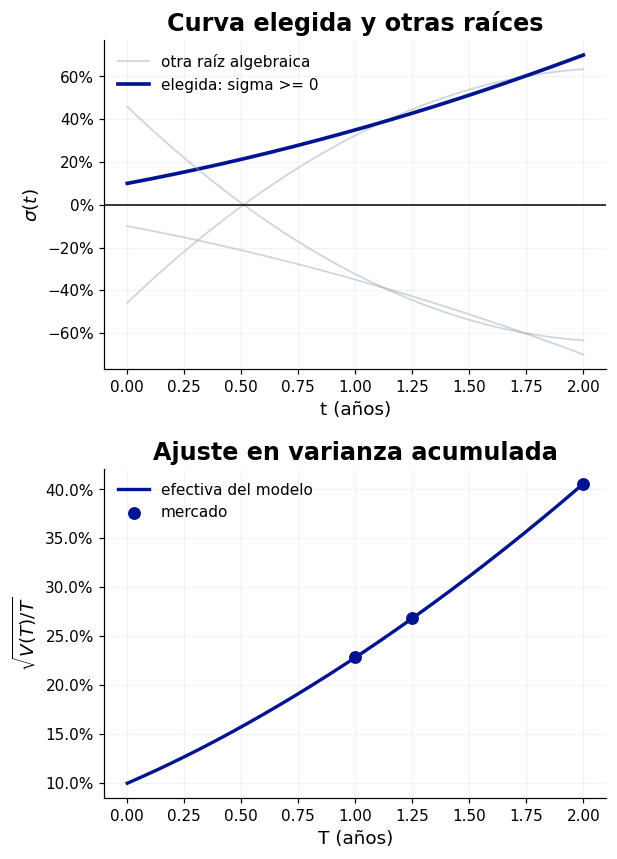

In [4]:
def sigma(t):
    t = np.asarray(t)
    return a*t**2 + b*t + c

V_fit = varianza_polinomio(VENCIMIENTOS, coef)
precios_fit = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, V_fit)
])
errores_precio = precios_fit - PRECIOS

assert np.min(sigma(grid)) > 0.0
assert np.all(np.diff(varianza_polinomio(grid, coef)) >= -1e-12)
assert np.max(np.abs(errores_precio)) < 2e-10

tabla_repricing = pd.DataFrame({
    "Mercado": PRECIOS,
    "Modelo": precios_fit,
    "Error": errores_precio,
    "sigma(T)": sigma(VENCIMIENTOS),
    "sigma efectiva [0,T]": np.sqrt(V_fit/VENCIMIENTOS),
}, index=VENCIMIENTOS)
tabla_repricing.index.name = "T"
display(tabla_repricing.style.format({
    "Mercado": "{:.4f}", "Modelo": "{:.10f}", "Error": "{:+.2e}",
    "sigma(T)": "{:.6%}", "sigma efectiva [0,T]": "{:.6%}",
}))

t_plot = np.linspace(0.0, 2.0, 500)
t_eff = np.linspace(1e-4, 2.0, 500)
fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))

for x in soluciones:
    sig_x = x[0]*t_plot**2 + x[1]*t_plot + x[2]
    es_admisible = np.min(sig_x) >= -1e-10
    axes[0].plot(
        t_plot, sig_x, lw=2.4 if es_admisible else 1.2,
        alpha=1.0 if es_admisible else 0.45,
        color="#001391" if es_admisible else "#93a6b9",
        label="elegida: sigma >= 0" if es_admisible else "otra raíz algebraica",
    )
axes[0].axhline(0.0, color="black", lw=1)
handles, labels = axes[0].get_legend_handles_labels()
unicos = dict(zip(labels, handles))
axes[0].legend(unicos.values(), unicos.keys())
axes[0].set(title="Curva elegida y otras raíces",
            xlabel="t (años)", ylabel="$\\sigma(t)$")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

vol_ef_curva = np.sqrt(varianza_polinomio(t_eff, coef)/t_eff)
axes[1].plot(t_eff, vol_ef_curva, color="#001391", lw=2.2,
             label="efectiva del modelo")
axes[1].scatter(VENCIMIENTOS, VOL_EFECTIVAS, color="#001391", s=55,
                zorder=3, label="mercado")
axes[1].set(title="Ajuste en varianza acumulada",
            xlabel="T (años)", ylabel="$\\sqrt{V(T)/T}$")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
plt.show()


---

## Apartado 3.4 — Valoración por simulación de la call asiática

### Mapa de la valoración

Antes de entrar en técnicas de precisión numérica, el precio de la asiática se construye con esta cadena:

$$
\boxed{
\sigma(t)
\to V(t_i)
\to \Delta V_i
\to Z_i
\to S_{t_i}
\to \overline S
\to (\overline S-K)^+
\to \text{media de payoffs}
\to \text{descuento}
}
$$

Éste es el **núcleo del ejercicio**. Antitéticos, control geométrico y RQMC no cambian el producto ni su esperanza: se añaden después para obtener la misma valoración con menos ruido numérico.


**Qué pide el enunciado.** Usar la volatilidad calibrada en 3.3 para valorar una asiática con $K=100$, fijaciones $t_1=1.15$, $t_2=1.30$, $t_3=1.60$, $t_4=1.70$ y pago en $T_{\mathrm{pago}}=2$ años.

La europea dependía solo de $S_T$. Esta opción depende simultáneamente de $S_{t_1},S_{t_2},S_{t_3},S_{t_4}$: necesitamos la **distribución conjunta** de varios precios de una misma trayectoria. Conocer sus distribuciones por separado no indica cómo se mueven juntos.

### 1. Entender el payoff y la fecha de pago

Definimos la media aritmética de las cuatro fijaciones:

$$\overline S=\frac14\sum_{i=1}^4S_{t_i}.$$

El payoff es

$$(\overline S-K)^+.$$

Para calcularlo en una trayectoria: obtenemos los cuatro precios, hacemos su media, restamos $K$ y truncamos en cero. El factor $1/4$ asigna el mismo peso a cada fijación. La expresión

$$\frac14\sum_{i=1}^4(S_{t_i}-K)^+$$

sería otro producto: la media de cuatro payoffs de calls. En la asiática, las fijaciones altas y bajas se compensan **antes** de aplicar la parte positiva.

$C_A$ denota el precio actual de la asiática. Bajo la misma medida neutral al riesgo que en 3.2,

$$C_A=e^{-rT_{\mathrm{pago}}}E[(\overline S-K)^+]
=e^{-0.02}E[(\overline S-100)^+].$$

El promedio queda conocido en $1.70$ años, pero se cobra en $2$: descontamos hasta la fecha de pago. No necesitamos simular $S_2$, porque no entra en el payoff y el tipo es determinista.

### 2. Identificar los shocks compartidos

Usamos $Y_i=I_{t_i}$ para abreviar el shock acumulado hasta cada fijación:

$$Y_i=\int_0^{t_i}\sigma(s)\,dW_s.$$

Es solo la parte aleatoria del exponente de 3.1. Cada $Y_i$ tiene media cero y varianza $V(t_i)$, pero los cuatro shocks no son independientes. Si $t_i<t_j$, ambos contienen todos los shocks anteriores a $t_i$:

$$Y_j=Y_i+\int_{t_i}^{t_j}\sigma(s)\,dW_s.$$

La integral adicional es independiente de $Y_i$, al usar un intervalo disjunto y un integrando determinista. La covarianza, que mide la variación compartida, es entonces

$$\operatorname{Cov}(Y_i,Y_j)
=\operatorname{Var}(Y_i)+0=V(t_i).$$

Reuniendo ambos órdenes posibles de las fechas,

$$\boxed{\operatorname{Cov}(Y_i,Y_j)=V(\min(t_i,t_j))}.$$

Esta es la covarianza de los shocks logarítmicos, no directamente la de los precios. Los precios también dependen entre sí porque se construyen con esos shocks compartidos. Simular cuatro lognormales independientes conservaría sus distribuciones individuales, pero cambiaría la distribución del promedio y el precio de su opción.

### 3. Construir una trayectoria mediante incrementos

Ponemos $t_0=0$. La varianza nueva aportada entre dos fijaciones es

$$\Delta V_i=V(t_i)-V(t_{i-1})
=\int_{t_{i-1}}^{t_i}\sigma^2(s)\,ds.$$

En ese mismo intervalo el shock nuevo es $\Delta Y_i=\int_{t_{i-1}}^{t_i}\sigma(s)\,dW_s$. Por el argumento de 3.2, tiene ley $N(0,\Delta V_i)$; los cuatro shocks nuevos son independientes.

Para simularlos generamos $Z_1,\ldots,Z_4$ normales estándar independientes y construimos

$$\Delta Y_i=\sqrt{\Delta V_i}\,Z_i.$$

Esta igualdad define la variable simulada con la distribución requerida. La raíz convierte varianza en desviación típica. Después acumulamos:

$$Y_1=\Delta Y_1,$$

$$Y_2=\Delta Y_1+\Delta Y_2,$$

$$Y_3=\Delta Y_1+\Delta Y_2+\Delta Y_3,$$

$$Y_4=\Delta Y_1+\Delta Y_2+\Delta Y_3+\Delta Y_4.$$

Por ejemplo, $Y_1$ e $Y_2$ comparten $\Delta Y_1$: esa construcción produce automáticamente la covarianza correcta. Convertimos ahora cada shock acumulado en un precio usando 3.1:

$$S_{t_i}=S_0\exp\left(rt_i-\frac12V(t_i)+Y_i\right).$$

Con los datos, $S_0=100$ y $r=0.01$. La integral de varianza se calcula analíticamente con el polinomio de 3.3; no se aproxima la SDE por Euler. La distribución conjunta simulada en las cuatro fechas es exacta para este modelo: queda error de muestreo, sin error de discretización temporal.

### 4. Sustituir la esperanza por una media muestral

El promedio aritmético de lognormales no es, en general, lognormal; la fórmula europea no puede aplicarse directamente a $\overline S$. Monte Carlo permite valorar su payoff sin suponer una distribución cerrada para ese promedio.

Repetimos la construcción para $M$ trayectorias. El superíndice $(m)$ identifica la trayectoria, mientras que $i$ sigue identificando la fijación. Para cada trayectoria calculamos

$$P^{(m)}=\left(\frac14\sum_{i=1}^4S_{t_i}^{(m)}-K\right)^+.$$

$P^{(m)}$ es su pago futuro. El estimador básico del precio es

$$\boxed{\widehat C_A=e^{-rT_{\mathrm{pago}}}
\frac1M\sum_{m=1}^MP^{(m)}}.$$

El sombrero indica una estimación numérica: sustituimos la esperanza por la media de los pagos simulados y descontamos. Para trayectorias pseudoaleatorias independientes, si $H_m=e^{-rT_{\mathrm{pago}}}P^{(m)}$, el error estándar es $s_H/\sqrt M$, donde $s_H$ es la desviación típica muestral de esos pagos descontados.

La tabla siguiente muestra $V(t_i)$ y $\Delta V_i$ sin redondear los coeficientes de entrada. La implementación utiliza precisamente estos incrementos: `sqrt(dv)` escala las normales, `cumsum` acumula los shocks y la exponencial genera los precios. Después añadiremos técnicas para reducir el ruido de la media, conservando este mismo payoff y esta misma dependencia.

También se calcula el precio geométrico que servirá de control: la siguiente explicación desarrolla su función y su fórmula.

In [5]:
T_FIX = np.array([1.15, 1.30, 1.60, 1.70])
T_PAGO = 2.0
DESCUENTO = np.exp(-r*T_PAGO)
V_FIX = varianza_polinomio(T_FIX, coef)
DELTA_V = np.diff(np.r_[0.0, V_FIX])

assert np.all(DELTA_V > 0)
assert np.all(sigma(T_FIX) > 0)

tabla_fix = pd.DataFrame({
    "sigma(t)": sigma(T_FIX),
    "V(t)": V_FIX,
    "Delta V": DELTA_V,
}, index=T_FIX)
tabla_fix.index.name = "Fijación"
display(tabla_fix.style.format({
    "sigma(t)": "{:.6%}", "V(t)": "{:.10f}", "Delta V": "{:.10f}",
}))

# Precio analítico del promedio geométrico: variable de control.
n_fix = len(T_FIX)
media_log_G = np.mean(np.log(S0) + r*T_FIX - 0.5*V_FIX)
var_log_G = np.minimum.outer(V_FIX, V_FIX).sum() / n_fix**2
sd_log_G = np.sqrt(var_log_G)
d2_G = (media_log_G - np.log(K)) / sd_log_G
d1_G = d2_G + sd_log_G
precio_geo = DESCUENTO * (
    np.exp(media_log_G + 0.5*var_log_G) * norm.cdf(d1_G)
    - K * norm.cdf(d2_G)
)

print(f"Precio analítico de la asiática geométrica de control: {precio_geo:.8f}")


,sigma(t),V(t),Delta V
Fijación,,,
1.150000,39.606065%,0.0730067303,0.0730067303
1.300000,44.443469%,0.0995035832,0.0264968529
1.600000,54.792720%,0.1734071144,0.0739035312
1.700000,58.442305%,0.2054642135,0.0320570990


Precio analítico de la asiática geométrica de control: 12.79677073


### Segunda capa — Precisión numérica y auditoría

A partir de aquí el precio ya está conceptualmente definido. Las técnicas siguientes solo buscan reducir y medir el error de simulación.

### 5. Reducir el ruido sin cambiar el producto

**Parejas antitéticas.** Evaluamos cada vector normal $Z$ junto con $-Z$. Ambos tienen la misma distribución; promediar sus payoffs conserva la esperanza y compensa parte de las oscilaciones. Cada pareja es una unidad estadística, no dos observaciones independientes.

**Control geométrico.** Introducimos $G=(\prod_iS_{t_i})^{1/4}$, la media geométrica de las mismas fijaciones. Se parece a la aritmética y suele moverse con ella, pero su call tiene un precio analítico conocido. Ese valor nos permite medir y corregir parte del ruido de simulación.

Como $\log G=\frac14\sum_i\log S_{t_i}$ es una combinación lineal de gaussianas conjuntas, es normal. Su media $m_G=E[\log G]$ se obtiene promediando las partes deterministas de los logaritmos:

$$m_G=\frac14\sum_{i=1}^4\left(\log100+0.01t_i-\frac12V(t_i)\right).$$

Su varianza $v_G=\operatorname{Var}(\log G)$ incluye todas las covarianzas compartidas:

$$v_G=\frac1{16}\sum_{i=1}^4\sum_{j=1}^4V(\min(t_i,t_j)).$$

El factor $1/16$ procede de los dos pesos $1/4$ al calcular la covarianza del promedio. Repetimos la integración lognormal de 3.2, ahora con media logarítmica $m_G$ y varianza $v_G$. Los umbrales son $d_{2,G}=(m_G-\log K)/\sqrt{v_G}$ y $d_{1,G}=d_{2,G}+\sqrt{v_G}$. El precio geométrico resulta

$$C_G=e^{-0.02}\left[e^{m_G+v_G/2}\Phi(d_{1,G})-K\Phi(d_{2,G})\right].$$

Aquí $e^{m_G+v_G/2}=E[G]$; el descuento sigue siendo hasta $2$. La celda anterior obtiene $C_G=12.79677073$.

Sean $H$ y $J$ los payoffs descontados aritmético y geométrico **promediados dentro de una pareja antitética**. Construimos el pago corregido

$$H^{\mathrm{cv}}=H-\beta(J-C_G).$$

$J-C_G$ mide la desviación del control simulado respecto a su esperanza conocida. Restar una cantidad de media cero conserva $E[H]$. $\beta$ determina cuánto corregimos; el valor que minimiza la varianza es $\operatorname{Cov}(H,J)/\operatorname{Var}(J)$, obtenido minimizando la función cuadrática $\operatorname{Var}(H)-2\beta\operatorname{Cov}(H,J)+\beta^2\operatorname{Var}(J)$. Se estima una sola vez con un piloto independiente de 200.000 parejas y se mantiene fijo en la valoración.

### 6. Sobol aleatorizado y error numérico

La implementación mantiene la construcción por incrementos anterior. Cambia cómo genera los vectores de entrada: Sobol distribuye puntos uniformes de forma regular en cuatro dimensiones; el *scrambling* los aleatoriza preservando esa estructura. Esto es cuasi-Monte Carlo aleatorizado, o RQMC.

Para transformar una coordenada uniforme $U_i$ en normal usamos $Z_i=\Phi^{-1}(U_i)$, donde $\Phi^{-1}$ es la función cuantil: el valor cuya probabilidad acumulada es $U_i$. Así, $P(Z_i\le z)=P(U_i\le\Phi(z))=\Phi(z)$. El código recorta las coordenadas a $[10^{-15},1-10^{-15}]$ para evitar cuantiles infinitos; es una protección numérica existente.

Usamos $R=32$ aleatorizaciones independientes, con $2^{16}=65\,536$ parejas por réplica, es decir, $131\,072$ trayectorias al contar cada vector y su antitético. Los puntos **dentro** de una réplica Sobol no son independientes: no aplicamos a sus filas la fórmula del error estándar del Monte Carlo independiente.

Cada réplica produce una media corregida $\widehat C_\ell$, con índice $\ell=1,\ldots,R$; usamos $\ell$ para no confundirlo con el tipo $r$. Promediamos esas estimaciones independientes:

$$\widehat C_A=\frac1R\sum_{\ell=1}^R\widehat C_\ell,
\qquad \operatorname{SE}=\frac{s_{\widehat C}}{\sqrt R}.$$

$s_{\widehat C}$ es la desviación típica muestral de los 32 precios. El intervalo aproximado del 95 % es

$$\widehat C_A\pm t_{0.975,31}\operatorname{SE},$$

con $t_{0.975,31}$ el cuantil 97,5 % de Student con $R-1=31$ grados de libertad. La aproximación se apoya en la distribución de las medias de réplica; no es un intervalo exacto por construcción.

Este intervalo describe **incertidumbre numérica por usar una muestra finita**, condicionada a los datos y al modelo. No mide incertidumbre de la curva ni posibles errores de modelización. La celda siguiente compara el precio con y sin control y calcula el intervalo entre réplicas.

In [6]:
def payoffs_antiteticos(z, coef_modelo=coef):
    '''Payoffs descontados por pareja antitética; una fila es una unidad MC.'''
    v = varianza_polinomio(T_FIX, coef_modelo)
    dv = np.diff(np.r_[0.0, v])
    if np.any(dv <= 0):
        raise ValueError("La varianza acumulada no es creciente en las fijaciones")
    resultados = []
    for normales in (z, -z):
        Y = np.cumsum(normales*np.sqrt(dv), axis=1)
        S = S0*np.exp(r*T_FIX - 0.5*v + Y)
        arit = DESCUENTO*np.maximum(S.mean(axis=1)-K, 0.0)
        geom = DESCUENTO*np.maximum(
            np.exp(np.log(S).mean(axis=1))-K, 0.0
        )
        resultados.append((arit, geom))
    payoff_arit = 0.5*(resultados[0][0] + resultados[1][0])
    payoff_geom = 0.5*(resultados[0][1] + resultados[1][1])
    return payoff_arit, payoff_geom

# Piloto independiente para fijar beta sin estimarlo con la muestra de producción.
rng_pilot = np.random.default_rng(20260302)
y_pilot, x_pilot = payoffs_antiteticos(
    rng_pilot.standard_normal((200_000, n_fix))
)
beta_cv = np.cov(y_pilot, x_pilot, ddof=1)[0, 1] / np.var(x_pilot, ddof=1)
corr_cv = np.corrcoef(y_pilot, x_pilot)[0, 1]

# Randomized quasi-Monte Carlo: réplicas Sobol con scrambles independientes.
N_SCRAMBLES = 32
POTENCIA_SOBOL = 16
N_PARES_REPLICA = 2**POTENCIA_SOBOL
medias_plain = []
medias_cv = []
for seed in range(N_SCRAMBLES):
    u = qmc.Sobol(
        d=n_fix, scramble=True, seed=30_000+seed
    ).random_base2(POTENCIA_SOBOL)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y, x = payoffs_antiteticos(z)
    medias_plain.append(y.mean())
    medias_cv.append((y-beta_cv*(x-precio_geo)).mean())

medias_plain = np.array(medias_plain)
medias_cv = np.array(medias_cv)

def resumen_replicas(valores):
    media = valores.mean()
    se = valores.std(ddof=1) / np.sqrt(len(valores))
    critico = student_t.ppf(0.975, df=len(valores)-1)
    return media, se, media-critico*se, media+critico*se

precio_plain, se_plain, lo_plain, hi_plain = resumen_replicas(medias_plain)
precio_asian, se_asian, lo_asian, hi_asian = resumen_replicas(medias_cv)

assert abs(precio_plain-precio_asian) < 5*np.sqrt(se_plain**2+se_asian**2)

print(f"Correlación piloto aritmética-geométrica: {corr_cv:.6f}")
print(f"Beta de control fijada en piloto: {beta_cv:.8f}")
print(f"RQMC + antitéticos ({N_SCRAMBLES} scrambles × "
      f"{2*N_PARES_REPLICA:,} paths):")
print(f"  Sin control: {precio_plain:.8f}  SE(rep)={se_plain:.8f}  "
      f"IC95%=[{lo_plain:.8f}, {hi_plain:.8f}]")
print(f"  Con control: {precio_asian:.8f}  SE(rep)={se_asian:.8f}  "
      f"IC95%=[{lo_asian:.8f}, {hi_asian:.8f}]")


Correlación piloto aritmética-geométrica: 0.997190
Beta de control fijada en piloto: 1.04122446
RQMC + antitéticos (32 scrambles × 131,072 paths):
  Sin control: 13.62196355  SE(rep)=0.00010176  IC95%=[13.62175601, 13.62217108]
  Con control: 13.62180500  SE(rep)=0.00007890  IC95%=[13.62164409, 13.62196591]


**Resultado para entregar: 13,62 unidades monetarias.** La media aritmética supera a la geométrica en cada trayectoria, por lo que su call no puede valer menos. El intervalo anterior mide solo error de simulación condicionado a la curva elegida; no incluye incertidumbre de cotizaciones ni riesgo de modelo.


### 7. Contraste independiente y sensibilidad a la curva elegida

Un Monte Carlo pseudoaleatorio con semilla distinta utiliza un millón de parejas antitéticas y el mismo control geométrico. Ahora las parejas sí son independientes, y el error estándar se calcula sobre sus payoffs corregidos:

$$\widehat C_{\mathrm{PRNG}}\approx13.622091,\qquad
\operatorname{SE}_{\mathrm{PRNG}}\approx0.001054.$$

El contraste con la estimación Sobol utiliza la diferencia dividida por la raíz de la suma de sus varianzas estimadas. Se obtiene aproximadamente $0.27$ errores estándar, compatible con el mismo precio.

Como sensibilidad adicional, una raíz cuadrática que cruza cero también ajusta las tres calls. Esa curva queda excluida por el criterio $\sigma(t)\ge0$, aunque es válida matemáticamente como coeficiente de difusión. Al cambiar $V(t_i)$ entre los vencimientos cotizados, la asiática resulta aproximadamente $13.740158$, frente a $13.621805$: una diferencia de $0.118353$, alrededor del $0.87\%$.

Cambiar globalmente el signo de una curva no modifica su cuadrado ni este precio. La diferencia anterior procede de otra forma de $\sigma^2(t)$ entre vencimientos. Este contraste muestra por qué el resultado debe acompañarse del criterio de selección de la curva y por qué un intervalo Monte Carlo estrecho no elimina el riesgo de modelo.

In [7]:
# Contraste pseudoaleatorio, semilla distinta del piloto y de Sobol.
N_PARES_PRNG = 1_000_000
rng_check = np.random.default_rng(20260303)
y_check, x_check = payoffs_antiteticos(
    rng_check.standard_normal((N_PARES_PRNG, n_fix))
)
y_check_cv = y_check - beta_cv*(x_check-precio_geo)
precio_check = y_check_cv.mean()
se_check = y_check_cv.std(ddof=1) / np.sqrt(N_PARES_PRNG)
lo_check = precio_check - 1.96*se_check
hi_check = precio_check + 1.96*se_check

diferencia_check = precio_check-precio_asian
z_check = diferencia_check / np.sqrt(se_check**2+se_asian**2)
assert abs(z_check) < 4.0

# Elegimos una de las dos raíces que cambian de signo; la otra es su opuesta global.
candidatas_cruce = [
    x for x in soluciones
    if np.min(x[0]*grid**2+x[1]*grid+x[2]) < 0
    and np.max(x[0]*grid**2+x[1]*grid+x[2]) > 0
    and x[2] > 0
]
assert len(candidatas_cruce) == 1
coef_cruce = candidatas_cruce[0]

medias_cruce = []
for seed in range(16):
    u = qmc.Sobol(d=n_fix, scramble=True, seed=40_000+seed).random_base2(15)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y_alt, _ = payoffs_antiteticos(z, coef_modelo=coef_cruce)
    medias_cruce.append(y_alt.mean())
precio_cruce, se_cruce, lo_cruce, hi_cruce = resumen_replicas(np.array(medias_cruce))

print(f"Contraste PRNG + antitéticos + control: {precio_check:.8f}  "
      f"SE={se_check:.8f}  IC95%=[{lo_check:.8f}, {hi_check:.8f}]")
print(f"Diferencia PRNG−RQMC estandarizada: {z_check:+.2f}")
print(f"Curva que cruza cero (rechazada) — asiática: "
      f"{precio_cruce:.6f}  IC95%=[{lo_cruce:.6f}, {hi_cruce:.6f}]")
print(f"Impacto frente al caso no negativo: "
      f"{precio_cruce-precio_asian:+.6f} "
      f"({(precio_cruce/precio_asian-1):+.3%})")


Contraste PRNG + antitéticos + control: 13.62209062  SE=0.00105350  IC95%=[13.62002576, 13.62415548]
Diferencia PRNG−RQMC estandarizada: +0.27
Curva que cruza cero (rechazada) — asiática: 13.740158  IC95%=[13.739146, 13.741171]
Impacto frente al caso no negativo: +0.118353 (+0.869%)


### Leer la precisión, no solo el precio

Arriba se muestra la media acumulada de las estimaciones: el control geométrico reduce sus oscilaciones. Abajo se comparan los payoffs por pareja antitética; ambos comparten muchos movimientos, que es lo que aprovecha el control. El histograma muestra hasta el percentil 99,5 % del payoff aritmético; el cálculo del precio utiliza la muestra completa.


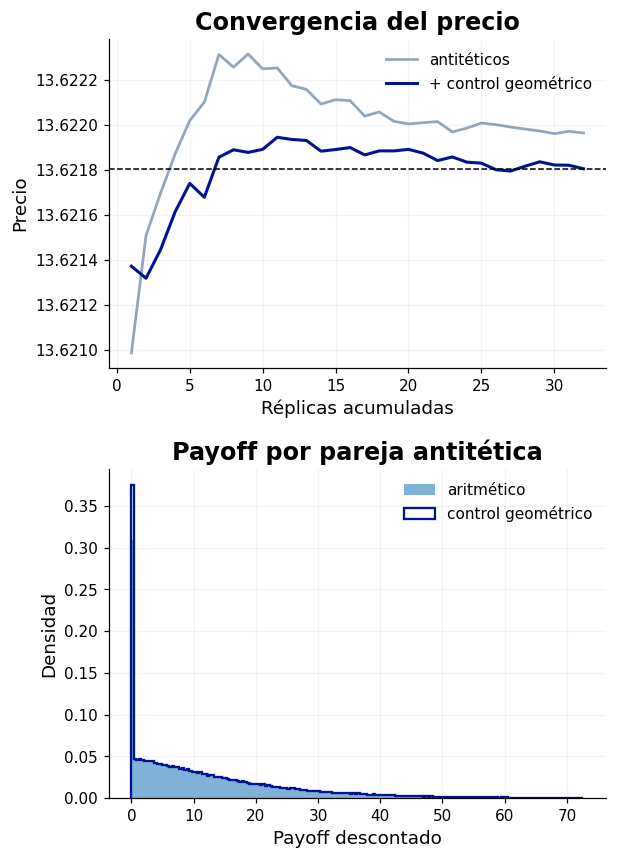

In [8]:
# Evidencia visual: estabilidad entre scrambles y distribución del payoff.
running_plain = np.cumsum(medias_plain) / np.arange(1, N_SCRAMBLES+1)
running_cv = np.cumsum(medias_cv) / np.arange(1, N_SCRAMBLES+1)

# Reutilizar 150.000 parejas del contraste independiente ya calculado.
n_hist = 150_000
y_hist, x_hist = y_check[:n_hist], x_check[:n_hist]

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_plain,
             color="#93a6b9", lw=1.8, label="antitéticos")
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_cv,
             lw=2.0, label="+ control geométrico")
axes[0].axhline(precio_asian, color="black", ls="--", lw=1)
axes[0].set(title="Convergencia del precio",
            xlabel="Réplicas acumuladas", ylabel="Precio")
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
axes[0].legend()

limite = np.quantile(y_hist, 0.995)
axes[1].hist(y_hist, bins=180, density=True, alpha=0.55,
             range=(0, limite), color="#1973b8",
             label="aritmético")
axes[1].hist(x_hist, bins=180, density=True, histtype="step", lw=1.5,
             range=(0, limite), color="#001391",
             label="control geométrico")
axes[1].set(title="Payoff por pareja antitética",
            xlabel="Payoff descontado", ylabel="Densidad")
axes[1].legend()

fig.tight_layout()
plt.show()


---

## Recorrido y conclusiones

| Apartado | Objeto construido | Qué permite hacer |
|---|---|---|
| 3.1 | Solución explícita de la SDE | Separar deriva, compensación de Itô y shock |
| 3.2 | Distribución terminal a partir de $V(T)$ | Integrar el payoff de la call europea |
| 3.3 | Curva $\sigma(t)$ a partir de tres precios | Recuperar tres varianzas y seleccionar una curva no negativa |
| 3.4 | Fijaciones conjuntas de esa misma curva | Promediar precios, aplicar el payoff y descontar a $T=2$ |

La calibración reproduce las tres calls. La asiática vale **13,62 unidades monetarias** para la curva seleccionada; los controles RQMC y pseudoaleatorio respaldan su precisión numérica. La sensibilidad a la raíz alternativa distingue esa precisión de la incertidumbre de modelización.

In [9]:
print("=" * 78)
print("RESUMEN EJERCICIO 3")
print("=" * 78)
print(f"Calibración no negativa: a={a:.9f}, b={b:.9f}, c={c:.9f}")
print("Volatilidades efectivas de mercado: "
      + ", ".join(f"{x:.4%}" for x in VOL_EFECTIVAS))
print(f"Error máximo de repricing europeo: {np.max(np.abs(errores_precio)):.2e}")
print(f"Call asiática aritmética: {precio_asian:.6f}")
print(f"IC 95% RQMC por réplicas: [{lo_asian:.6f}, {hi_asian:.6f}]")
print(f"Contraste PRNG: {precio_check:.6f} ± {1.96*se_check:.6f}")
print(f"Sensibilidad a raíz con cruce (rechazada): {precio_cruce:.6f}")


RESUMEN EJERCICIO 3
Calibración no negativa: a=0.049958717, b=0.200094752, c=0.099881280
Volatilidades efectivas de mercado: 22.8324%, 26.8310%, 40.5723%
Error máximo de repricing europeo: 2.13e-14
Call asiática aritmética: 13.621805
IC 95% RQMC por réplicas: [13.621644, 13.621966]
Contraste PRNG: 13.622091 ± 0.002065
Sensibilidad a raíz con cruce (rechazada): 13.740158


## Cobertura del enunciado

Cada fila identifica las celdas de este notebook por su ID estable.

| Apartado del enunciado | Notebook / celdas que responden | Estado |
|---|---|---|
| 3.1 · Verificar SDE y condición inicial | Ejercicio 3: `b5e82c91` | PASS |
| 3.2 · Derivar precio analítico de la call | Ejercicio 3: `357f8281` | PASS |
| 3.3 · Calibrar a, b, c y reproducir las tres cotizaciones | Ejercicio 3: `09ef3b8a; 0910f481; a57e850c` | PASS |
| 3.4 · Simular fijaciones conjuntas, payoff y pago a 2 años | Ejercicio 3: `18fb481d; bca49e0d` | PASS |
| 3.4 · Resultado e incertidumbre; contraste independiente | Ejercicio 3: `761e3779; a0e09722; 53099190` | PASS |

Este notebook incluye los datos, las explicaciones, los cálculos y las figuras necesarios para su ejercicio. Puede ejecutarse desde un kernel limpio sin archivos auxiliares.